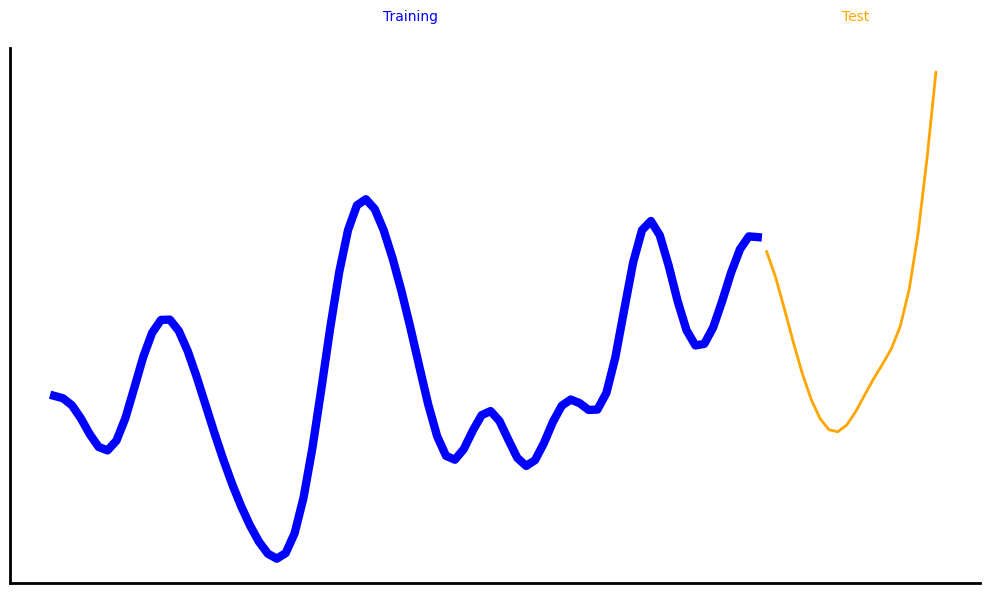

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 生成平滑时间序列
np.random.seed(4234)
raw_series = np.random.randn(100)
fs = 1.0
cutoff = 0.1
order = 4

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

smoothed_series = butter_lowpass_filter(raw_series, cutoff, fs, order)

# 训练/测试集划分
train_size = 80
smoothed_train_data = smoothed_series[:train_size]
smoothed_test_data = smoothed_series[train_size:]

# 绘图
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()

# 白色背景
ax.set_facecolor('white')

# 绘制训练集（蓝色实线）
plt.plot(range(train_size), smoothed_train_data, color='blue', linewidth=6)

# 绘制测试集（橙色实线，而非虚线）
plt.plot(range(train_size, len(smoothed_series)), smoothed_test_data, color='orange', linewidth=2)

# 箭头标注
y_arrow = smoothed_series.max() + 0.2
plt.annotate('', xy=(train_size-1, y_arrow), xytext=(0, y_arrow),
             arrowprops=dict(arrowstyle='<->', color='blue', linewidth=2))
plt.text(train_size/2, y_arrow + 0.05, 'Training', ha='center', color='blue')

plt.annotate('', xy=(len(smoothed_series)-1, y_arrow), xytext=(train_size, y_arrow),
             arrowprops=dict(arrowstyle='<->', color='orange', linewidth=2))
plt.text(train_size + (len(smoothed_series)-train_size)/2, y_arrow + 0.05, 
         'Test', ha='center', color='orange')

# 去掉坐标轴刻度和文字
# 去掉所有边框，仅保留左 y 轴线和底部 x 轴线
for spine in ax.spines.values():
    spine.set_visible(False)
    
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# 设置坐标轴线为粗线
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# 去除刻度线和刻度标签（只隐藏刻度，不隐藏轴线）
ax.tick_params(axis='both',
               which='both',
               length=0,           # 不显示刻度线
               labelbottom=False,  # 不显示 x 轴刻度数字
               labelleft=False)    # 不显示 y 轴刻度数字

# 去掉网格线
plt.grid(False)

# 去掉标题和图例等多余元素
plt.tight_layout()
plt.savefig('time_series_gt.png')

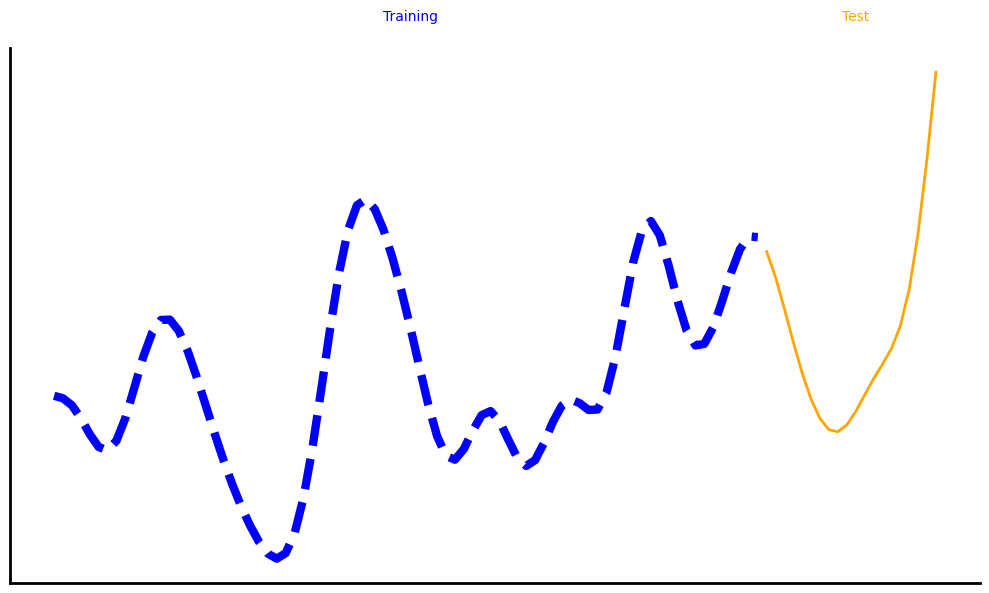

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 生成平滑时间序列
np.random.seed(4234)
raw_series = np.random.randn(100)
fs = 1.0
cutoff = 0.1
order = 4

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

smoothed_series = butter_lowpass_filter(raw_series, cutoff, fs, order)

# 训练/测试集划分
train_size = 80
smoothed_train_data = smoothed_series[:train_size]
smoothed_test_data = smoothed_series[train_size:]

# 绘图
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()

# 白色背景
ax.set_facecolor('white')

# 绘制训练集（蓝色实线）
plt.plot(range(train_size), smoothed_train_data, color='blue', linewidth=6, linestyle='--')

# 绘制测试集（橙色实线，而非虚线）
plt.plot(range(train_size, len(smoothed_series)), smoothed_test_data, color='orange', linewidth=2)
# 箭头标注
y_arrow = smoothed_series.max() + 0.2
plt.annotate('', xy=(train_size-1, y_arrow), xytext=(0, y_arrow),
             arrowprops=dict(arrowstyle='<->', color='blue', linewidth=2))
plt.text(train_size/2, y_arrow + 0.05, 'Training', ha='center', color='blue')

plt.annotate('', xy=(len(smoothed_series)-1, y_arrow), xytext=(train_size, y_arrow),
             arrowprops=dict(arrowstyle='<->', color='orange', linewidth=2))
plt.text(train_size + (len(smoothed_series)-train_size)/2, y_arrow + 0.05, 
         'Test', ha='center', color='orange')

# 去掉坐标轴刻度和文字
# plt.xticks([])
# plt.yticks([])
# 去掉所有边框，仅保留左 y 轴线和底部 x 轴线
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# 设置坐标轴线为粗线
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# 去除刻度线和刻度标签（只隐藏刻度，不隐藏轴线）
ax.tick_params(axis='both',
               which='both',
               length=0,           # 不显示刻度线
               labelbottom=False,  # 不显示 x 轴刻度数字
               labelleft=False)    # 不显示 y 轴刻度数字

# 去除刻度线和数字
ax.tick_params(axis='both', which='both',
               bottom=False, top=False, left=False, right=False,  # 无刻度线
               labelbottom=False, labelleft=False)                # 无数字标签

# 去掉网格线
plt.grid(False)

# 去掉标题和图例等多余元素
plt.tight_layout()
plt.savefig('time_series_est.png')